# Deep versus wide networks
### Question 1


In [1]:
import math
import random

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import wandb
import matplotlib.pyplot as plt

# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cpu")
print("Using device:", device)


Using device: cpu


In [2]:
class NoisyXORDataset(Dataset):
    """
    Dataset for the noisy XOR problem.

    Each sample is generated as:
        (x1, x2, y) = (m1 + s * eta1, m2 + s * eta2, m1 xor m2)
    where m1, m2 ∈ {0,1}, eta1, eta2 ~ N(0, 1).
    """
    def __init__(self, n_samples=1000, s=0.1, seed=None):
        super().__init__()
        if seed is not None:
            g = torch.Generator()
            g.manual_seed(seed)
        else:
            g = None

        # Sample cluster centers m1, m2 ∈ {0, 1}
        m = torch.randint(0, 2, (n_samples, 2), generator=g, dtype=torch.float32)  # shape (N,2)
        m1 = m[:, 0]
        m2 = m[:, 1]

        # Gaussian noise
        eta = torch.randn(n_samples, 2, generator=g)

        # Inputs
        x = m + s * eta  # (x1, x2)

        # XOR label
        y = (m1 != m2).float()  # shape (N,)

        self.x = x
        self.y = y

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


In [3]:
def plot_dataset(dataset, title="Dataset", ax=None):
    """
    Scatter plot of (x1, x2) colored by class y (0 or 1).
    """
    x_all = dataset.x.numpy()
    y_all = dataset.y.numpy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    class0 = x_all[y_all == 0]
    class1 = x_all[y_all == 1]

    ax.scatter(class0[:, 0], class0[:, 1], label="Class 0", alpha=0.7, edgecolor="k")
    ax.scatter(class1[:, 0], class1[:, 1], label="Class 1", alpha=0.7, edgecolor="k")

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

    if ax is None:
        plt.show()


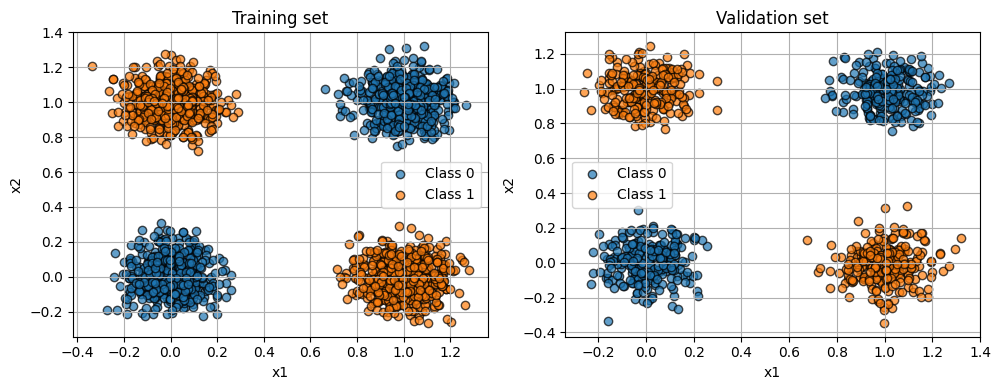

In [4]:
# Hyperparameters for data
n_train = 2000
n_val = 1000
s = 0.1  # standard deviation of noise

train_dataset = NoisyXORDataset(n_samples=n_train, s=s, seed=seed)
val_dataset = NoisyXORDataset(n_samples=n_val, s=s, seed=seed + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_dataset(train_dataset, title="Training set", ax=axes[0])
plot_dataset(val_dataset, title="Validation set", ax=axes[1])
plt.tight_layout()
plt.show()


In [5]:
class FeedForwardNet(nn.Module):
    """
    Simple feed-forward neural network for binary classification on 2D input.

    Default: 2 → 3 → 1 with tanh hidden activation and identity output.
    We apply sigmoid in the loss (using BCEWithLogitsLoss).
    """
    def __init__(self, input_dim=2, hidden_sizes=(3,), output_dim=1, activation=nn.Tanh):
        super().__init__()

        layers = []
        in_features = input_dim

        # Hidden layers
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            layers.append(activation())
            in_features = h

        # Output layer (identity activation)
        layers.append(nn.Linear(in_features, output_dim))
        # Identity at the end is implicit; BCEWithLogitsLoss expects raw logits

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)  # logits (no sigmoid here)


In [6]:
hidden_sizes = (3, 3, 3)
model = FeedForwardNet(input_dim=2, hidden_sizes=hidden_sizes, output_dim=1).to(device)
print(model)


FeedForwardNet(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=3, bias=True)
    (1): Tanh()
    (2): Linear(in_features=3, out_features=3, bias=True)
    (3): Tanh()
    (4): Linear(in_features=3, out_features=3, bias=True)
    (5): Tanh()
    (6): Linear(in_features=3, out_features=1, bias=True)
  )
)


In [7]:
batch_size = 64
n_epochs = 100
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [8]:
# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()  # expects logits and float targets in [0,1]
learning_rate = 1e-2
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


In [9]:
wandb.init(
    project="dl-assignment1-xor",
    name="xor_depth3_width3",
    config={
        "model": "FeedForwardNet",
        "depth": 3,
        "width": 3,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "n_epochs": n_epochs,
    },
)

wandb.watch(model, log="all", log_freq=10)

wandb: Currently logged in as: last24ag (last24ag-copenhagen-business-school) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer, n_epochs=100):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(1, n_epochs + 1):
        # ---- Training ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(x_batch).squeeze(1)  # (batch,)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x_batch.size(0)

            # Accuracy
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total

        # ---- Validation ----
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(x_batch).squeeze(1)
                loss = criterion(logits, y_batch)

                val_running_loss += loss.item() * x_batch.size(0)

                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()
                val_correct += (preds == y_batch).sum().item()
                val_total += y_batch.size(0)

        epoch_val_loss = val_running_loss / val_total
        epoch_val_acc = val_correct / val_total

        wandb.log(
            {
                "epoch": epoch,
                "train_loss": epoch_train_loss,
                "val_loss": epoch_val_loss,
                "train_acc": epoch_train_acc,
                "val_acc": epoch_val_acc,
            }
        )
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accuracies.append(epoch_train_acc)
        val_accuracies.append(epoch_val_acc)
        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:3d}/{n_epochs} | "
                f"Train loss: {epoch_train_loss:.4f}, acc: {epoch_train_acc:.3f} | "
                f"Val loss: {epoch_val_loss:.4f}, acc: {epoch_val_acc:.3f}"
            )

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accuracies,
        "val_acc": val_accuracies,
    }
    return history

history = train_model(model, train_loader, val_loader, criterion, optimizer, n_epochs=n_epochs)


Epoch   1/100 | Train loss: 0.6912, acc: 0.569 | Val loss: 0.6756, acc: 0.550
Epoch  10/100 | Train loss: 0.3553, acc: 0.682 | Val loss: 0.3646, acc: 0.743
Epoch  20/100 | Train loss: 0.0100, acc: 1.000 | Val loss: 0.0091, acc: 1.000
Epoch  30/100 | Train loss: 0.0016, acc: 1.000 | Val loss: 0.0016, acc: 1.000
Epoch  40/100 | Train loss: 0.0009, acc: 1.000 | Val loss: 0.0009, acc: 1.000
Epoch  50/100 | Train loss: 0.0006, acc: 1.000 | Val loss: 0.0006, acc: 1.000
Epoch  60/100 | Train loss: 0.0005, acc: 1.000 | Val loss: 0.0005, acc: 1.000
Epoch  70/100 | Train loss: 0.0004, acc: 1.000 | Val loss: 0.0004, acc: 1.000
Epoch  80/100 | Train loss: 0.0003, acc: 1.000 | Val loss: 0.0003, acc: 1.000
Epoch  90/100 | Train loss: 0.0002, acc: 1.000 | Val loss: 0.0002, acc: 1.000
Epoch 100/100 | Train loss: 0.0002, acc: 1.000 | Val loss: 0.0002, acc: 1.000


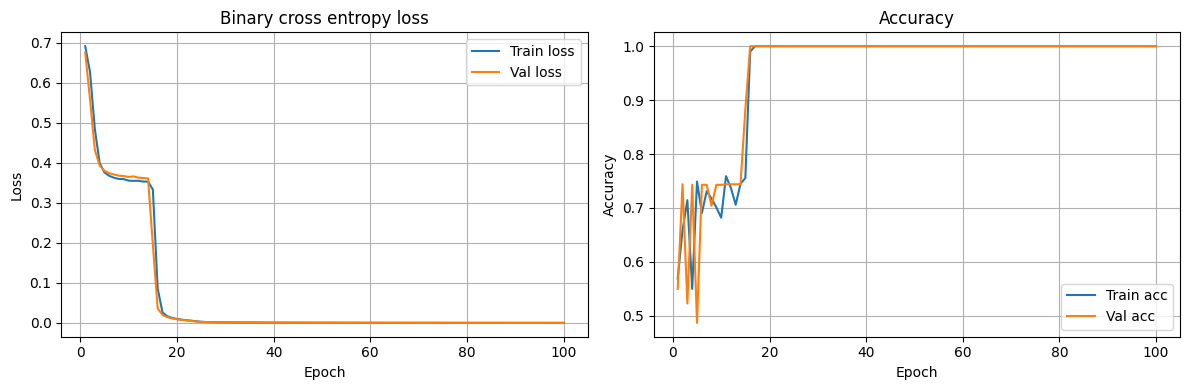

In [11]:
epochs = np.arange(1, n_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs, history["train_loss"], label="Train loss")
axes[0].plot(epochs, history["val_loss"], label="Val loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Binary cross entropy loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, history["train_acc"], label="Train acc")
axes[1].plot(epochs, history["val_acc"], label="Val acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### Question 3.2

In [12]:
def build_model(depth, width, input_dim=2, output_dim=1):
    """
    Build a feed-forward net with `depth` hidden layers, each of size `width`.
    depth = 0 -> no hidden layers: just Linear(2 -> 1).
    """
    if depth == 0:
        hidden_sizes = ()
    else:
        hidden_sizes = (width,) * depth

    model = FeedForwardNet(
        input_dim=input_dim,
        hidden_sizes=hidden_sizes,
        output_dim=output_dim
    ).to(device)

    return model


In [13]:
def train_once_and_eval(depth, width,
                        n_train=2000,
                        s=0.1,
                        n_epochs=100,
                        batch_size=64,
                        learning_rate=1e-2,
                        n_eval=2000):
    """
    Train one model with given depth/width and return the loss on a NEW dataset.
    """
    # 1) New training data for this run
    train_dataset = NoisyXORDataset(n_samples=n_train, s=s)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # 2) Build model, loss, optimizer
    model = build_model(depth=depth, width=width)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # 3) Train (simple loop; no validation here)
    model.train()
    for epoch in range(n_epochs):
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(x_batch).squeeze(1)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

    # 4) Evaluate on a *new* dataset
    eval_dataset = NoisyXORDataset(n_samples=n_eval, s=s)
    eval_loader = DataLoader(eval_dataset, batch_size=256, shuffle=False)

    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for x_batch, y_batch in eval_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(x_batch).squeeze(1)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * x_batch.size(0)
            total += x_batch.size(0)

    eval_loss = total_loss / total
    return eval_loss


In [14]:
import numpy as np
import pandas as pd

depth_values = [0, 1, 2, 3]
width_values = [1, 2, 3]
n_repeats = 5          # you can increase to 10 if you have time/compute
s = 0.1                # same noise level as before
n_train = 2000
n_eval = 2000
n_epochs = 100
batch_size = 64
learning_rate = 1e-2

results = []

for depth in depth_values:
    for width in width_values:
        print(f"\n=== Depth {depth}, Width {width} ===")
        losses = []
        for r in range(n_repeats):
            print(f"  Run {r+1}/{n_repeats} ...", end="")
            eval_loss = train_once_and_eval(
                depth=depth,
                width=width,
                n_train=n_train,
                s=s,
                n_epochs=n_epochs,
                batch_size=batch_size,
                learning_rate=learning_rate,
                n_eval=n_eval,
            )
            losses.append(eval_loss)
            print(f"  eval loss = {eval_loss:.4f}")

        mean_loss = float(np.mean(losses))
        std_loss = float(np.std(losses))

        results.append({
            "depth": depth,
            "width": width,
            "mean_eval_loss": mean_loss,
            "std_eval_loss": std_loss,
        })

df_results = pd.DataFrame(results)
df_results



=== Depth 0, Width 1 ===
  Run 1/5 ...  eval loss = 0.6952
  Run 2/5 ...  eval loss = 0.6925
  Run 3/5 ...  eval loss = 0.6946
  Run 4/5 ...  eval loss = 0.6947
  Run 5/5 ...  eval loss = 0.6935

=== Depth 0, Width 2 ===
  Run 1/5 ...  eval loss = 0.6934
  Run 2/5 ...  eval loss = 0.6921
  Run 3/5 ...  eval loss = 0.6929
  Run 4/5 ...  eval loss = 0.6926
  Run 5/5 ...  eval loss = 0.6940

=== Depth 0, Width 3 ===
  Run 1/5 ...  eval loss = 0.6931
  Run 2/5 ...  eval loss = 0.6945
  Run 3/5 ...  eval loss = 0.6943
  Run 4/5 ...  eval loss = 0.6941
  Run 5/5 ...  eval loss = 0.6932

=== Depth 1, Width 1 ===
  Run 1/5 ...  eval loss = 0.4840
  Run 2/5 ...  eval loss = 0.4905
  Run 3/5 ...  eval loss = 0.4784
  Run 4/5 ...  eval loss = 0.5027
  Run 5/5 ...  eval loss = 0.4799

=== Depth 1, Width 2 ===
  Run 1/5 ...  eval loss = 0.0033
  Run 2/5 ...  eval loss = 0.3537
  Run 3/5 ...  eval loss = 0.0050
  Run 4/5 ...  eval loss = 0.3373
  Run 5/5 ...  eval loss = 0.3437

=== Depth 1, Width 

,depth,width,mean_eval_loss,std_eval_loss
0,0,1,0.694096,0.000953
1,0,2,0.693011,0.000646
2,0,3,0.693816,0.000574
3,1,1,0.487085,0.008841
4,1,2,0.208616,0.167031
5,1,3,0.070815,0.138357
6,2,1,0.475763,0.007299
7,2,2,0.165546,0.205024
8,2,3,0.002143,0.002187
9,3,1,0.482707,0.007897


### Question 3.4


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class MinimalXORNet(nn.Module):
    """
    Minimal XOR network:
    2 -> 2 (tanh) -> 1 (identity)
    """
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2, bias=True)   # hidden layer
        self.act = nn.Tanh()
        self.fc2 = nn.Linear(2, 1, bias=True)  # output layer (identity)
        
    def forward(self, x):
        h = self.act(self.fc1(x))
        out = self.fc2(h)  # logits
        return out


Using device: cpu


In [16]:
def plot_xor_boundaries(model, dataset, epoch=None, ax=None,
                        x_min=-0.5, x_max=1.5, n_points=300):
    """
    Plot training data + decision boundaries:
    - two hidden unit boundaries: a1(x)=0, a2(x)=0
    - output decision boundary: p(y=1|x)=0.5
    """
    model.eval()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    
    # Scatter data
    X = dataset.x.numpy()
    y = dataset.y.numpy()
    class0 = X[y == 0]
    class1 = X[y == 1]
    ax.scatter(class0[:, 0], class0[:, 1], label="class 0", alpha=0.7, edgecolor="k")
    ax.scatter(class1[:, 0], class1[:, 1], label="class 1", alpha=0.7, edgecolor="k")
    
    # Grid for boundaries
    x1 = np.linspace(x_min, x_max, n_points)
    x2 = np.linspace(x_min, x_max, n_points)
    xx1, xx2 = np.meshgrid(x1, x2)
    grid = np.stack([xx1.ravel(), xx2.ravel()], axis=1)  # (N,2)
    
    with torch.no_grad():
        grid_t = torch.from_numpy(grid).float().to(device)
        
        # Hidden pre-activations: a = xW^T + b
        W1 = model.fc1.weight       # (2,2)
        b1 = model.fc1.bias         # (2,)
        a = grid_t @ W1.t() + b1    # (N,2)
        a = a.cpu().numpy()
        a1 = a[:, 0].reshape(xx1.shape)
        a2 = a[:, 1].reshape(xx1.shape)
        
        # Output probabilities
        logits = model(grid_t).squeeze(1)      # (N,)
        probs = torch.sigmoid(logits).cpu().numpy().reshape(xx1.shape)
    
    # Hidden unit boundaries: a1=0, a2=0
    cs1 = ax.contour(xx1, xx2, a1, levels=[0.0],
                     linestyles="--", linewidths=2)
    cs2 = ax.contour(xx1, xx2, a2, levels=[0.0],
                     linestyles="-.", linewidths=2)
    
    # Output decision boundary: p=0.5
    cs3 = ax.contour(xx1, xx2, probs, levels=[0.5],
                     colors="k", linewidths=2)
    
    # Labels for legend
    cs1.collections[0].set_label("hidden 1 boundary")
    cs2.collections[0].set_label("hidden 2 boundary")
    cs3.collections[0].set_label("output boundary (p=0.5)")
    
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    title = "Decision boundaries"
    if epoch is not None:
        title += f" (epoch {epoch})"
    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(x_min, x_max)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True)
    
    return ax


In [17]:
# Reuse your NoisyXORDataset from earlier:
# class NoisyXORDataset(Dataset): ...

# Training data
train_dataset = NoisyXORDataset(n_samples=2000, s=0.1, seed=123)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

model_xor = MinimalXORNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_xor.parameters(), lr=1e-2)

n_epochs = 100
snapshot_every = 5   # save weights every 5 epochs

snapshots = []       # list of state_dicts
snapshot_epochs = [] # corresponding epochs

for epoch in range(1, n_epochs + 1):
    model_xor.train()
    running_loss = 0.0
    total = 0
    
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model_xor(x_batch).squeeze(1)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * x_batch.size(0)
        total += x_batch.size(0)
    
    epoch_loss = running_loss / total
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{n_epochs} - train loss: {epoch_loss:.4f}")
    
    # Save snapshot
    if epoch % snapshot_every == 0 or epoch == 1:
        snapshots.append({k: v.cpu().clone() for k, v in model_xor.state_dict().items()})
        snapshot_epochs.append(epoch)


Epoch   1/100 - train loss: 0.7092
Epoch  10/100 - train loss: 0.4574
Epoch  20/100 - train loss: 0.1130
Epoch  30/100 - train loss: 0.0392
Epoch  40/100 - train loss: 0.0214
Epoch  50/100 - train loss: 0.0139
Epoch  60/100 - train loss: 0.0098
Epoch  70/100 - train loss: 0.0074
Epoch  80/100 - train loss: 0.0057
Epoch  90/100 - train loss: 0.0046
Epoch 100/100 - train loss: 0.0038


/var/folders/ck/_b2fnrn152vbbcxt5jf9gfth0000gn/T/ipykernel_24195/1897348935.py:53: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  cs1.collections[0].set_label("hidden 1 boundary")
/var/folders/ck/_b2fnrn152vbbcxt5jf9gfth0000gn/T/ipykernel_24195/1897348935.py:54: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  cs2.collections[0].set_label("hidden 2 boundary")
/var/folders/ck/_b2fnrn152vbbcxt5jf9gfth0000gn/T/ipykernel_24195/1897348935.py:55: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  cs3.collections[0].set_label("output boundary (p=0.5)")


IndexError: list index out of range

Error in callback <function _draw_all_if_interactive at 0x13b3c9e40> (for post_execute), with arguments args (),kwargs {}:


IndexError: list index out of range

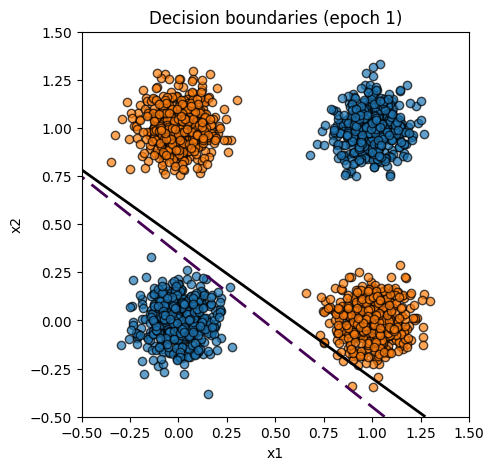

In [ ]:
from matplotlib.animation import PillowWriter


fig, ax = plt.subplots(figsize=(5, 5))

def init():
    ax.clear()
    # load first snapshot
    model_xor.load_state_dict(snapshots[0])
    plot_xor_boundaries(model_xor, train_dataset, epoch=snapshot_epochs[0], ax=ax)
    return ax,

def update(frame):
    ax.clear()
    model_xor.load_state_dict(snapshots[frame])
    plot_xor_boundaries(model_xor, train_dataset, epoch=snapshot_epochs[frame], ax=ax)
    return ax,

anim = animation.FuncAnimation(
    fig,
    update,
    init_func=init,
    frames=len(snapshots),
    interval=200,   # milliseconds between frames
    blit=False
)

# Save as MP4 (for handing in)
anim.save("xor_decision_evolution.gif", writer=PillowWriter(fps=5))

plt.close(fig)  # avoid double display


In [ ]:
# Choose 3–4 snapshots to include in the report
selected_indices = [0, len(snapshots)//10, 2*len(snapshots)//3, len(snapshots)-1]

for idx in selected_indices:
    epoch = snapshot_epochs[idx]
    model_xor.load_state_dict(snapshots[idx])
    
    fig, ax = plt.subplots(figsize=(5, 5))
    plot_xor_boundaries(model_xor, train_dataset, epoch=epoch, ax=ax)
    fig.tight_layout()
    fig.savefig(f"xor_boundaries_epoch_{epoch}.png", dpi=150)
    plt.close(fig)
    print(f"Saved xor_boundaries_epoch_{epoch}.png")
